# Working with complicated dataset

your name: Matija Malisic

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [15]:
### Your code here . . .
import pandas as pd
import requests
from io import StringIO
import re

url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"
text = requests.get(url).text
lines = text.splitlines()
fields_raw = next(l for l in lines if "Fields:" in l)
fields_part = re.search(r'Fields:\s*(.*?)"\s*,', fields_raw).group(1)
columns = [c.strip() for c in fields_part.split(",")]
data_lines = [l for l in lines if not l.lstrip().startswith("#") and not l.lstrip().startswith('"#')]
df = pd.read_csv(StringIO("\n".join(data_lines)), header=None)
df = df.dropna(axis=1, how="all")
df = df.iloc[:, :len(columns)]
df.columns = columns
df = df.drop(columns=["query acc.ver"])
df = df.set_index("subject acc.ver")
df = df[[c for c in df.columns if c != "publications"] + ["publications"]]
df.head()



,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3


### Question 2
What is the average number of publications?

In [26]:
### Your code here . . .
publication = (
    df["publications"]
    .astype(str)
    .str.strip()
    .replace({"-": None, "": None})
)
pub_num = pd.to_numeric(publication, errors="coerce")
pub_num.mean()

np.float64(26.989690721649485)

The average number of publications is 26.9

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [28]:
### Your code here . . .
bonds_num = pd.to_numeric(
    df["bonds"].astype(str).str.replace(",", "", regex=False).str.strip(),
    errors="coerce"
)

df.index[bonds_num > 15000].tolist()


['AGK29621.1',
 'AHG32084.1',
 '6G2J_H',
 'YP_002791042.1',
 'AGK29634.1',
 '0806162F',
 'YP_009112408.1',
 'YP_001876469.1',
 'YP_009092269.1',
 'AHG32149.1',
 'YP_009092074.1',
 'YP_009450474.1',
 'YP_004123270.1',
 'YP_009092073.1',
 'AHZ60901.1',
 'YP_004123350.1',
 'YP_009453754.1',
 'ADD46492.1',
 'YP_007025968.1',
 'YP_009453806.1',
 'YP_007024956.1',
 'ASM92364.1',
 'YP_006073044.1',
 'ASM92494.1',
 'ADG95699.1',
 'YP_004891275.1',
 'YP_009166014.1',
 'YP_009538416.1',
 'YP_009414182.1',
 'YP_009178854.1',
 'YP_009414415.1',
 'YP_009353908.1',
 'YP_009093743.1',
 'ABX45285.1',
 'YP_009414156.1',
 'YP_009414363.1']

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

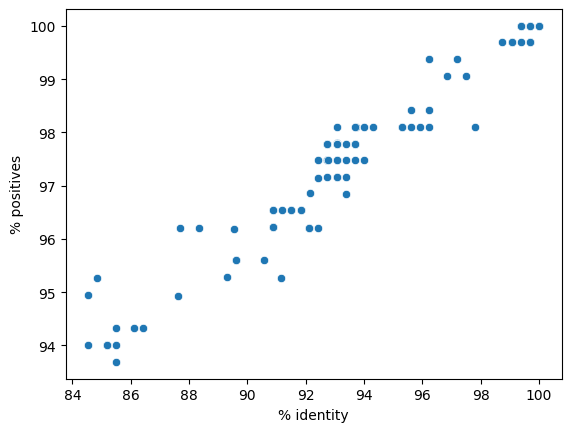

Correlation: 0.9697833837305724


In [30]:
### Your code here . . .
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

x = pd.to_numeric(df["% identity"], errors="coerce")
y = pd.to_numeric(df["% positives"], errors="coerce")

sns.scatterplot(x=x, y=y)
plt.xlabel("% identity")
plt.ylabel("% positives")
plt.show()

print("Correlation:", x.corr(y))

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [31]:
### Your code here . . .
import pandas as pd

ps_url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"

ps = pd.read_csv(ps_url)
df = df.merge(ps, how="left", left_index=True, right_on="Protein")
df = df.set_index("Protein").drop(columns=["Protein"], errors="ignore")
df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Unnamed: 0,Source
Protein,,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9,0.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47,NaN,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13,2.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41,NaN,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3,NaN,NaN
